## Uczenie maszynowe – zastosowania
### Zajęcia laboratoryjne
# 3. Regresja liniowa – zadanie

## Zadanie 3

### Część podstawowa (4 punkty)

Plik `fires_thefts.csv` zawiera rzeczywiste dane zebrane przez *U.S. Commission on Civil Rights*, przedstawiające liczbę pożarów w danej dzielnicy na tysiąc gospodarstw domowych (pierwsza kolumna) oraz liczbę włamań w tej samej dzielnicy na tysiąc mieszkańców (druga kolumna). 

Stwórz model (regresja liniowa) przewidujący liczbę włamań na podstawie liczby pożarów:
 * Oblicz parametry $\theta$ krzywej regresyjnej za pomocą metody gradientu prostego (*gradient descent*). Możesz wybrać wersję iteracyjną lub macierzową algorytmu.
 * Wykorzystując uzyskaną krzywą regresyjną przepowiedz liczbę włamań na tysiąc mieszkańców dla dzielnicy, w której występuje średnio 50, 100, 200 pożarów na tysiąc gospodarstw domowych.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie danych
data = pd.read_csv('fires_thefts.csv', header=None,
                   names=['fires', 'thefts']).dropna()
print(data.head())
print('Liczba przykładów:', len(data))


   fires  thefts
0    6.2      29
1    9.5      44
2   10.5      36
3    7.7      37
4    8.6      53
Liczba przykładów: 42


In [2]:
# Przygotowanie macierzy X (z kolumną jedynek) oraz wektora y
x_raw = data['fires'].to_numpy(dtype=float)
y = data['thefts'].to_numpy(dtype=float).reshape(-1, 1)
m = len(y)

# Standaryzacja cechy (zero mean, unit std) – kluczowa dla gradient descent
x_mean = x_raw.mean()
x_std  = x_raw.std()
x = (x_raw - x_mean) / x_std          # znormalizowana cecha
X = np.column_stack([np.ones(m), x])  # (m, 2)

print(f'Zakres x_raw: [{x_raw.min():.1f}, {x_raw.max():.1f}]')
print(f'Zakres x (po standaryzacji): [{x.min():.2f}, {x.max():.2f}]')

# Funkcja kosztu (MSE / 2)
def cost(theta, X, y):
    err = X @ theta - y
    return ((err.T @ err) / (2 * len(y))).item()

# Macierzowy gradient prosty
def gradient_descent(X, y, alpha, n_iter, theta0=None):
    theta = np.zeros((X.shape[1], 1)) if theta0 is None else theta0.copy()
    history = np.full(n_iter, np.nan)
    m = len(y)
    for i in range(n_iter):
        grad = (X.T @ (X @ theta - y)) / m
        theta = theta - alpha * grad
        history[i] = cost(theta, X, y)
    return theta, history


Zakres x_raw: [2.0, 39.7]
Zakres x (po standaryzacji): [-1.12, 2.83]


In [3]:
# Trenowanie modelu – po standaryzacji wszystkie trzy alpha zbiegają normalnie
alpha = 0.01
n_iter = 1_000
theta, history = gradient_descent(X, y, alpha=alpha, n_iter=n_iter)

print(f'theta_0 (bias)   = {theta[0,0]:.6f}')
print(f'theta_1 (scaled) = {theta[1,0]:.6f}')
print(f'J(theta) = {cost(theta, X, y):.6f}')

# Przeliczenie theta z powrotem na oryginalne jednostki
# h(x_raw) = theta_0 + theta_1 * (x_raw - mean) / std
# = (theta_0 - theta_1 * mean/std) + (theta_1 / std) * x_raw
theta1_orig = theta[1, 0] / x_std
theta0_orig = theta[0, 0] - theta1_orig * x_mean
print(f'\nW oryginalnych jednostkach:')
print(f'theta_0 = {theta0_orig:.6f}')
print(f'theta_1 = {theta1_orig:.6f}')


theta_0 (bias)   = 33.665213
theta_1 (scaled) = 12.545456
J(theta) = 180.410079

W oryginalnych jednostkach:
theta_0 = 16.994424
theta_1 = 1.313399


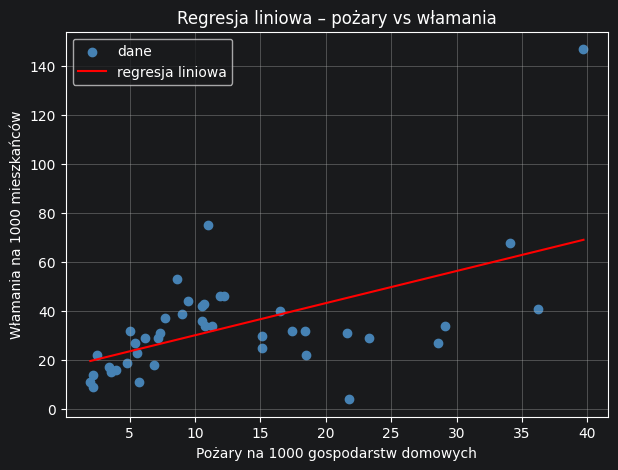

In [4]:
# Wykres dopasowanej prostej (na oryginalnych jednostkach)
xs_raw = np.linspace(x_raw.min(), x_raw.max(), 100)
ys_line = theta0_orig + theta1_orig * xs_raw

plt.figure(figsize=(7, 5))
plt.scatter(x_raw, y, label='dane', color='steelblue')
plt.plot(xs_raw, ys_line, color='red', label='regresja liniowa')
plt.xlabel('Pożary na 1000 gospodarstw domowych')
plt.ylabel('Włamania na 1000 mieszkańców')
plt.title('Regresja liniowa – pożary vs włamania')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# Predykcje dla 50, 100, 200 pożarów na 1000 gospodarstw domowych
for fires in [50, 100, 200]:
    pred = theta0_orig + theta1_orig * fires
    print(f'{fires:>3d} pożarów -> ~{pred:.2f} włamań na 1000 mieszkańców')


 50 pożarów -> ~82.66 włamań na 1000 mieszkańców
100 pożarów -> ~148.33 włamań na 1000 mieszkańców
200 pożarów -> ~279.67 włamań na 1000 mieszkańców


### Część zaawansowana (2 punkty)

Dla różnych wartości długości kroku $\alpha \in \{ 0.001, 0.01 , 0.1 \}$ stwórz wykres, który zilustruje progresję wartości $J(\theta)$ dla pierwszych 200 króków algorytmu gradientu prostego:
 * Oś $x$ wykresu to kolejne kroki algorytmu – od 0 do 200.
 * Oś $y$ wykresu to wartosci $J(\theta)$.
 * Wykres powinien skłądać się z trzech krzywych:
   1. dla $\alpha = 0.001$
   2. dla $\alpha = 0.01$
   3. dla $\alpha = 0.1$

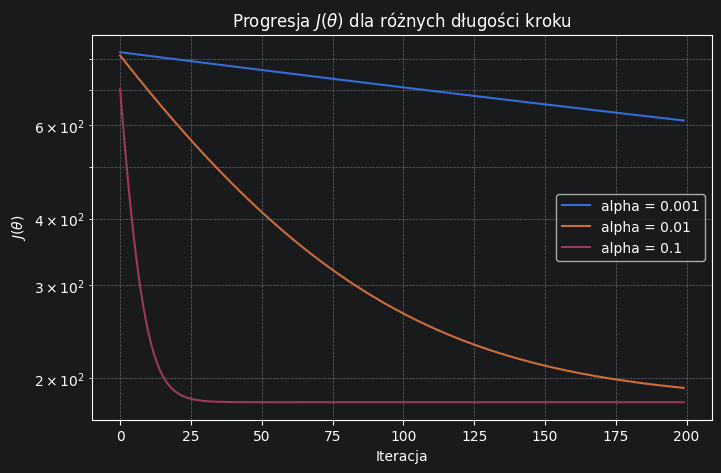

In [6]:
# Progresja J(theta) dla różnych długości kroku
# Po standaryzacji cech wszystkie trzy alpha zbiegają i dają trzy czytelne krzywe.
alphas = [0.001, 0.01, 0.1]
n_iter = 200

plt.figure(figsize=(8, 5))
for a in alphas:
    _, hist = gradient_descent(X, y, alpha=a, n_iter=n_iter)
    plt.plot(range(n_iter), hist, label=f'alpha = {a}')

plt.xlabel('Iteracja')
plt.ylabel(r'$J(\theta)$')
plt.title(r'Progresja $J(\theta)$ dla różnych długości kroku')
plt.yscale('log')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()


**Wnioski:**

* Po standaryzacji cech wszystkie trzy długości kroku zbiegają do minimum.
* Dla $\alpha = 0.001$ algorytm zbiega najwolniej – po 200 krokach nadal daleko od minimum.
* Dla $\alpha = 0.01$ zbieżność jest wyraźnie szybsza.
* Dla $\alpha = 0.1$ algorytm zbiega najszybciej – niemal osiąga minimum już po kilkudziesięciu krokach.
* Standaryzacja cech jest kluczowym krokiem przed gradient descent: bez niej duże wartości cech (fires ≈ 6–39) powodują, że nawet $\alpha = 0.01$ wywołuje rozbieżność (przepełnienie float64).
